# Suitability Index: Land Cover with Feedstock Integration

This notebook processes renewable energy feedstock data and integrates it with land cover suitability indices for Thailand. It calculates potential energy generation based on biomass, biogas, and waste feedstock availability by province and grid location.

## Step 1: Import Required Libraries

Load necessary libraries for spatial analysis (GeoPandas, Shapely), data handling (Pandas, NumPy), and raster processing (Rasterio, Rioxarray).

In [1]:
import xarray as xr
import geopandas as gpd
import pandas as pd
import numpy as np
import shapely.geometry
import shapely
import rasterio
import rioxarray
from rasterio.features import shapes
from shapely.geometry import shape
import matplotlib.pyplot as plt
from pathlib import Path

## Step 2: Load SI and Land Cover Data

Load the pre-processed suitability index dataset from Step 1 and convert it to a GeoDataFrame with point geometries at each grid cell location.

In [2]:
xr_final_SI = xr.open_dataset('Output\\xr_SI_Landcover_beforefeedstock.nc')
print(xr_final_SI)

df_landuse_suitability_index = xr_final_SI.to_dataframe()
df_landuse_suitability_index.reset_index(inplace=True)
df_landuse_suitability_index = gpd.GeoDataFrame(df_landuse_suitability_index, geometry =gpd.points_from_xy(df_landuse_suitability_index['lon'],df_landuse_suitability_index['lat']))
df_landuse_suitability_index.crs = {'init': 'epsg:4326'}

print(df_landuse_suitability_index)

<xarray.Dataset> Size: 463MB
Dimensions:     (lat: 5346, lon: 2985)
Coordinates:
  * lat         (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon         (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    lccs_class  (lat, lon) uint8 16MB ...
    SI_BGEC     (lat, lon) int32 64MB ...
    SI_Biomass  (lat, lon) int32 64MB ...
    SI_Solar    (lat, lon) int32 64MB ...
    SI_Wind     (lat, lon) int32 64MB ...
    SI_BGWW     (lat, lon) int32 64MB ...
    SI_MSW      (lat, lon) int32 64MB ...
    SI_IEW      (lat, lon) int32 64MB ...
                lat         lon  lccs_class  SI_BGEC  SI_Biomass  SI_Solar  \
0          5.615278   97.345833           0        0           0         0   
1          5.615278   97.348611           0        0           0         0   
2          5.615278   97.351389           0        0           0         0   
3          5.615278   97.354167           0        0           0         0   
4          5.61

d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


## Step 3: Load Thailand Administrative Boundaries

Load the Thailand province shapefile and extract province centroids for spatial joins to assign each grid point to its province.

In [3]:
## Load Thailand provincial boundaries
thailandmap = gpd.read_file('Data\\tha_admbnda_adm1_rtsd_20220121\\tha_admbnda_adm1_rtsd_20220121.shp')
thailandmap = thailandmap.to_crs('EPSG:4326')  # Modern CRS syntax
print(f'Loaded {len(thailandmap)} provinces')

Loaded 77 provinces


## 4. Spatial Join - Assign Grid Points to Provinces

In [4]:
from rasterio.transform import from_bounds
from scipy.spatial import cKDTree
import time

print('⏱️ Step 4: Assigning grid points to provinces...')
t0 = time.time()

# Setup grid and transform
lat = xr_final_SI['lat'].values
lon = xr_final_SI['lon'].values
height, width = len(lat), len(lon)
transform = from_bounds(lon.min(), lat.min(), lon.max(), lat.max(), width=width, height=height)

# Create province ID mapping
thailandmap['prov_id'] = range(len(thailandmap))
prov_id_to_name = dict(zip(range(len(thailandmap)), thailandmap['ADM1_TH']))

# Fast point-based assignment using spatial index
print(f'  Building province KDTree...')
prov_centroids = np.column_stack((thailandmap.geometry.centroid.x, thailandmap.geometry.centroid.y))
prov_tree = cKDTree(prov_centroids)

# Assign all grid points via KDTree (faster than full rasterization)
print(f'  Assigning {len(df_landuse_suitability_index)} points...')
grid_coords = np.column_stack((df_landuse_suitability_index['lon'].values, df_landuse_suitability_index['lat'].values))
_, nearest_prov_idx = prov_tree.query(grid_coords, k=1)

# Create output DataFrame
df_landuse_suitability_index_2 = df_landuse_suitability_index.copy()
df_landuse_suitability_index_2['prov_id'] = nearest_prov_idx
df_landuse_suitability_index_2['ADM1_TH'] = df_landuse_suitability_index_2['prov_id'].map(prov_id_to_name)
df_landuse_suitability_index_2['ADM1_EN'] = df_landuse_suitability_index_2['prov_id'].map(dict(zip(range(len(thailandmap)), thailandmap['ADM1_EN'])))

# Keep relevant columns only
keep_cols = ['lat', 'lon', 'lccs_class', 'SI_Solar', 'SI_Wind', 'SI_BGEC', 'SI_Biomass', 'SI_BGWW', 'SI_MSW', 'SI_IEW', 'ADM1_EN', 'ADM1_TH']
df_landuse_suitability_index_2 = df_landuse_suitability_index_2[keep_cols]

elapsed = time.time() - t0
print(f'✓ Assigned {len(df_landuse_suitability_index_2)} points in {elapsed:.2f}s')

⏱️ Step 4: Assigning grid points to provinces...
  Building province KDTree...


C:\Users\595078\AppData\Local\Temp\ipykernel_24136\2719985579.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  prov_centroids = np.column_stack((thailandmap.geometry.centroid.x, thailandmap.geometry.centroid.y))


  Assigning 15957810 points...
✓ Assigned 15957810 points in 5.71s


## 5. Verify Province Coverage

In [5]:
print('no of province = ',len(df_landuse_suitability_index_2['ADM1_TH'].unique()))

no of province =  77


## 6. Initialize Feedstock Area Columns

Create area columns for each feedstock type:
- **A_BGEC**: Biogas from Agriculture
- **A_Biomass**: Biomass from shrubland, grassland, agriculture
- **A_BGWW**: Biogas from wastewater
- **A_MSW**: Municipal Solid Waste
- **A_IEW**: Industrial/Effluent Waste

In [ ]:
# Define feedstock suitability mapping using vectorized approach
lccs_resolution = 300  # meters
areapergrid = (lccs_resolution / 1000) ** 2

# Define LCCS class mappings for each feedstock type
feedstock_mapping = {
    'A_BGEC': [10, 11, 12, 20, 30, 40],
    'A_Biomass': [110, 130, 120, 121, 122, 200, 201, 202, 140, 150, 151, 152, 153, 10, 11, 12, 20, 30, 40, 180],
    'A_BGWW': [10, 11, 12, 20, 30, 40],
    'A_MSW': [190],
    'A_IEW': [190],
}

# Vectorized initialization using numpy where
lccs = df_landuse_suitability_index_2['lccs_class'].values
for col, classes in feedstock_mapping.items():
    df_landuse_suitability_index_2[col] = np.where(np.isin(lccs, classes), areapergrid, 0.0).astype('float64')

print(f'✓ Initialized {len(feedstock_mapping)} feedstock area columns')

# Load and clean feedstock data
feedstock = pd.read_csv('Data\\สรุปข้อมูลพลังงาน -  ฐานข้อมูลพลังงานประเทศไทย.csv', header=0)


feedstock = feedstock.loc[feedstock['แหล่งพลังงานหลัก'].isin(['ชีวมวล','ก๊าซชีวภาพ','ขยะ'])].copy()
feedstock.reset_index(inplace=True, drop=True)

# Clean feedstock numeric data - convert to float, replace errors with NaN
feedstock['ศักยภาพพลังงานทดแทน (ktoe)'] = pd.to_numeric(feedstock['ศักยภาพพลังงานทดแทน (ktoe)'], errors='coerce')

# Remove rows with null energy potential
feedstock = feedstock.dropna(subset=['ศักยภาพพลังงานทดแทน (ktoe)'])

print(f'✓ Loaded feedstock: {len(feedstock)} records | {len(feedstock["จังหวัด"].unique())} provinces')
print(f'  Fuel types: {list(feedstock["แหล่งพลังงานหลัก"].unique())}')

list_province = df_landuse_suitability_index_2['ADM1_TH'].unique()
list_fueltype = feedstock['แหล่งพลังงานหลัก'].unique()

✓ Initialized 5 feedstock area columns


ValueError: Unable to parse string "1,365.10" at position 0

## 7. Verify Total Areas

In [7]:
print("total A_Biomass = ", df_landuse_suitability_index_2['A_Biomass'].sum())
print("total A_BGEC = ", df_landuse_suitability_index_2['A_BGEC'].sum())
print("total A_BGWW = ", df_landuse_suitability_index_2['A_BGWW'].sum())
print("total A_MSW = ", df_landuse_suitability_index_2['A_MSW'].sum())
print("total A_IEW = ", df_landuse_suitability_index_2['A_IEW'].sum())

total A_Biomass =  137398.0499999999
total A_BGEC =  130619.42999999982
total A_BGWW =  130619.42999999982
total A_MSW =  725.8499999999995
total A_IEW =  725.8499999999995


## 8. Distribute Feedstock Potential

Allocate provincial feedstock (ktoe) across grid cells proportional to suitable area per province.

In [8]:
# Map feedstock types to Thai names
FEEDSTOCK_TYPE = {
    'A_Biomass': 'ชีวมวล',
    'A_BGEC': 'ก๊าซชีวภาพ',
    'A_BGWW': 'ก๊าซชีวภาพ',
    'A_MSW': 'ขยะ',
    'A_IEW': 'ขยะ',
}

print('✓ Step 8: Distributing feedstock potential...')
for col, thai_type in FEEDSTOCK_TYPE.items():
    # Identify suitable cells
    mask = df_landuse_suitability_index_2[col] > 0
    if not mask.any():
        print(f'  {col}: No suitable cells')
        continue
    
    # Calculate suitable area per province (in km²)
    areas = df_landuse_suitability_index_2[mask].groupby('ADM1_TH')[col].sum() / areapergrid
    
    # Get feedstock potential (already numeric from Step 6)
    potentials_df = feedstock[feedstock['แหล่งพลังงานหลัก'] == thai_type].copy()
    potentials = potentials_df.set_index('จังหวัด')['ศักยภาพพลังงานทดแทน (ktoe)']
    
    # Distribute feedstock across grid cells
    matches = 0
    for prov in areas.index:
        if prov in potentials.index:
            area_val = float(areas[prov])
            pot_val = float(potentials[prov])
            
            if area_val > 0 and pot_val > 0:
                per_grid_val = pot_val / area_val
                df_landuse_suitability_index_2.loc[mask & (df_landuse_suitability_index_2['ADM1_TH'] == prov), col] = per_grid_val
                matches += 1
    
    if matches > 0:
        print(f'  {col}: Distributed to {matches} provinces')

# Report final totals
print('✓ Distribution complete:')
for col in ['A_Biomass', 'A_BGEC', 'A_BGWW', 'A_MSW', 'A_IEW']:
    total = df_landuse_suitability_index_2[col].sum()
    print(f'  {col}: {total:.2f} ktoe')

✓ Step 8: Distributing feedstock potential...
  A_Biomass: Distributed to 64 provinces
  A_BGEC: Distributed to 77 provinces
  A_BGWW: Distributed to 77 provinces
  A_MSW: Distributed to 74 provinces
  A_IEW: Distributed to 74 provinces
✓ Distribution complete:
  A_Biomass: 56251.91 ktoe
  A_BGEC: 1840.17 ktoe
  A_BGWW: 1840.17 ktoe
  A_MSW: 5865.38 ktoe
  A_IEW: 5865.38 ktoe


## 9. Display Final Feedstock Data

In [17]:
print(df_landuse_suitability_index_2)

                lat         lon  lccs_class  SI_Solar  SI_Wind  SI_BGEC  \
0          5.615278   97.345833           0         0        0        0   
1          5.615278   97.348611           0         0        0        0   
2          5.615278   97.351389           0         0        0        0   
3          5.615278   97.354167           0         0        0        0   
4          5.615278   97.356944           0         0        0        0   
...             ...         ...         ...       ...      ...      ...   
15957805  20.462500  105.623611           0         0        0        0   
15957806  20.462500  105.626389           0         0        0        0   
15957807  20.462500  105.629167           0         0        0        0   
15957808  20.462500  105.631944           0         0        0        0   
15957809  20.462500  105.634722           0         0        0        0   

          SI_Biomass  SI_BGWW  SI_MSW  SI_IEW    ADM1_EN ADM1_TH  A_BGEC  \
0                  0   

## 10. Convert to Xarray Format

In [18]:
df_landuse_suitability_index_2 = df_landuse_suitability_index_2.drop(columns='ADM1_TH')
df_landuse_suitability_index_2 = df_landuse_suitability_index_2.set_index(['lat', 'lon'])
xr_areafeedstock = xr.Dataset.from_dataframe(df_landuse_suitability_index_2)
print(xr_areafeedstock.data_vars)
print(xr_areafeedstock)

Data variables:
    lccs_class  (lat, lon) uint8 16MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Solar    (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Wind     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGEC     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_Biomass  (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_BGWW     (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_MSW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    SI_IEW      (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    ADM1_EN     (lat, lon) object 128MB 'Phuket' 'Phuket' ... 'Bueng Kan'
    A_BGEC      (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    A_Biomass   (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    A_BGWW      (lat, lon) float64 128MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    A_MSW       (lat, lon) 

## 11. Export to NetCDF

In [19]:
xr_areafeedstock.to_netcdf(path='Output\\xr_SI_Landcover.nc')

## 12. Visualize Feedstock Distribution

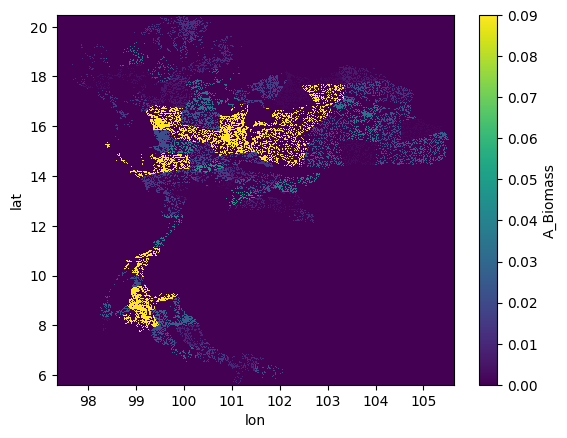

In [21]:
xr_areafeedstock['A_Biomass'].plot()

## 13. Reload Processed Data

In [22]:
xr_areafeedstock = xr.open_dataset('Output\\xr_SI_Landcover.nc')

## 14. Provincial-Level Analysis

Select province → Extract bounds → Subset data → Create map visualization.

(103.09676066900005, 16.181673239000077, 104.24064016800008, 17.101957866000078)
<xarray.Dataset> Size: 23MB
Dimensions:     (lat: 332, lon: 412)
Coordinates:
  * lat         (lat) float64 3kB 16.18 16.18 16.19 16.19 ... 17.1 17.1 17.1
  * lon         (lon) float64 3kB 103.1 103.1 103.1 103.1 ... 104.2 104.2 104.2
Data variables: (12/14)
    lccs_class  (lat, lon) uint8 137kB ...
    SI_Solar    (lat, lon) int32 547kB ...
    SI_Wind     (lat, lon) int32 547kB ...
    SI_BGEC     (lat, lon) int32 547kB ...
    SI_Biomass  (lat, lon) int32 547kB ...
    SI_BGWW     (lat, lon) int32 547kB ...
    ...          ...
    ADM1_EN     (lat, lon) <U24 13MB ...
    A_BGEC      (lat, lon) float64 1MB ...
    A_Biomass   (lat, lon) float64 1MB ...
    A_BGWW      (lat, lon) float64 1MB ...
    A_MSW       (lat, lon) float64 1MB ...
    A_IEW       (lat, lon) float64 1MB ...


d:\workstation\RESITING\.env\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\595078\AppData\Local\Temp\ipykernel_2212\2745719952.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  print(province.unary_union.bounds)
C:\Users\595078\AppData\Local\Temp\ipykernel_2212\2745719952.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  min_lon = province.unary_union.bounds[0]
C:\Users\595078\AppData\Local\Temp\ipykernel_2212\2745719952.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  max_lon = province.u

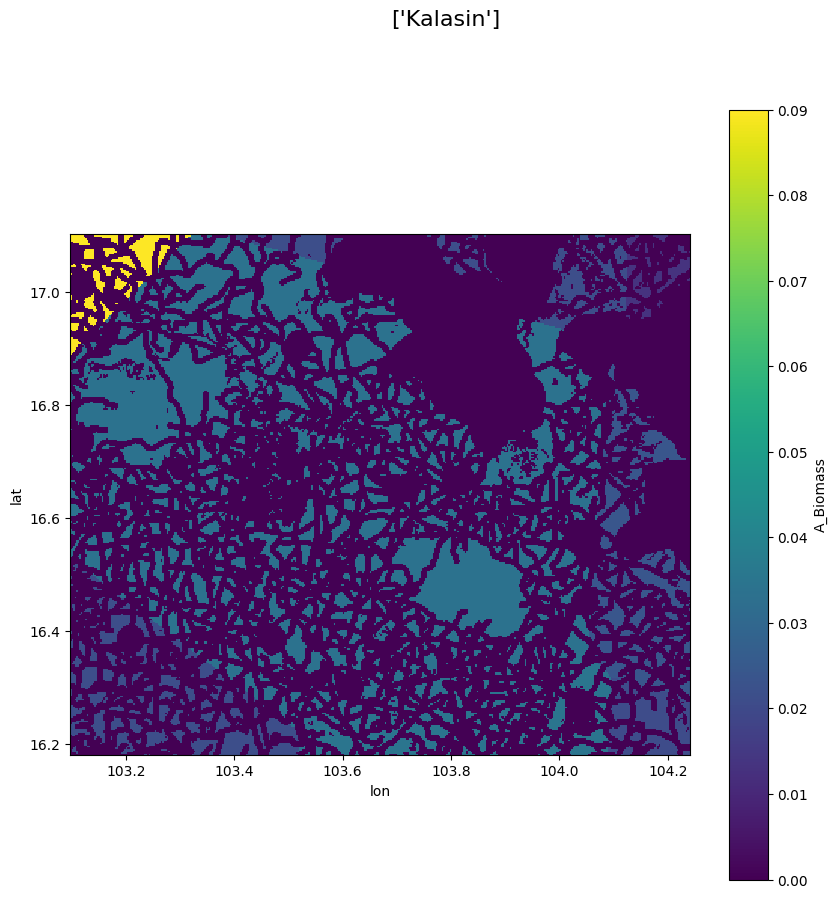

In [23]:
thailandmap = gpd.read_file('Data\\tha_admbnda_adm1_rtsd_20220121\\tha_admbnda_adm1_rtsd_20220121.shp')
thailandmap.crs = {'init': 'epsg:4326'}

province = 'Kalasin'
province = thailandmap.loc[thailandmap['ADM1_EN'] == province]
print(province.unary_union.bounds)
min_lon = province.unary_union.bounds[0]
max_lon = province.unary_union.bounds[2]
max_lat = province.unary_union.bounds[3]
min_lat = province.unary_union.bounds[1]

xr_buffer = xr_areafeedstock.sel(lat=slice(min_lat,max_lat), lon=slice(min_lon,max_lon))
print(xr_buffer)

fig, ax = plt.subplots(figsize=(10,10))
fig.suptitle(province['ADM1_EN'].values, fontsize=16)
province.plot(ax = ax, color='none', edgecolor = 'black', zorder = 0)
xr_buffer['A_Biomass'].plot(ax = ax,zorder = 1)